# Hackathon

## Introduction

**The problem**
The pandemic was killing people, resources (like hospital beds) were becoming in short supply - particularly in developing countries - and models that could predict risk and thus who should be prioritised were based on hospitalized pations, not the general population, rendering them ineffective for application to the generatl population. The Israeli Ministry of Health publicly released data on all those tested with the nasopharyngeal swab and other symptoms. The majority had indications for testing. All negative and positive cases were confirmed via lab tests.

Most important:
- cought and fever, contact with an individual confirmed to have COVID-19 (transmittability), male sex (sex bias)

**The dataset**

**What I learned about various models/techniques/etc.**

**The AUC score of the final model**


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import (
    CalibratedClassifierCV,
    CalibrationDisplay,
)
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier


## Config

In [2]:
RANDOM_STATE = 24

DATA_PATH = (
    "/data/users/max.white/apprenticeship/courses/"
    "9_hackathon/"
    "corona_tested_individuals_ver_006.english.csv"
)

GRID = {
    "model__max_depth": [1, 3, 5],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__n_estimators": [100, 200, 300],
    # "model__subsample": [0.8, 1.0],
    # "model__colsample_bytree": [0.8, 1.0],
}

## Functions

### Data prep

In [3]:
def prep_data(
    df,
    remove_ambiguous=True,
    test_size=0.2,
    validation_size=0.2,
):
    """
    Create separate training, validation and test sets.

    The test set is held back for final evaluation only.

    validation_size is the proportion of the remaining training
    data assigned to validation after the test set is removed.
    """

    df = df.copy()

    if remove_ambiguous:
        df = df[
            df["corona_result"].isin(
                ["negative", "positive"]
            )
        ].copy()
    else:
        raise ValueError(
            "This workflow is for binary classification. "
            "Set remove_ambiguous=True."
        )

    y = df["corona_result"].map(
        {
            "negative": 0,
            "positive": 1,
        }
    )

    X = df.drop(
        columns=[
            "corona_result",
            "test_date",
        ]
    )

    # Create the final, untouched test set.
    (
        X_train_val,
        X_test,
        y_train_val,
        y_test,
    ) = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Create the training and validation sets.
    (
        X_train,
        X_validation,
        y_train,
        y_validation,
    ) = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=RANDOM_STATE,
        stratify=y_train_val,
    )

    print(f"Training rows: {len(X_train)} ({len(X_train)/len(X):.1%})")
    print(f"Validation rows: {len(X_validation)} ({len(X_validation)/len(X):.1%})")
    print(f"Test rows: {len(X_test)} ({len(X_test)/len(X):.1%})")

    print("Training positive rate:", round(y_train.mean(), 4))
    print("Validation positive rate:", round(y_validation.mean(), 4))
    print("Test positive rate:", round(y_test.mean(), 4))

    return (
        X_train,
        X_validation,
        X_test,
        y_train,
        y_validation,
        y_test,
    )

def build_preprocessor():
    """
    One-hot encode categorical columns and leave symptom columns
    unchanged (as it is already binary).

    Missing categorical values are represented by their own
    one-hot encoded category.
    """

    categorical_columns = [
        "age_60_and_above",
        "gender",
        "test_indication",
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_columns,
            )
        ],
        remainder="passthrough",
        verbose_feature_names_out=False,
    )

    return preprocessor


### Building the model

In [ ]:
# ============================================================
# Basic piping to XGBClassifier
# ============================================================

def build_model(
    y_train,
    scale_pos_weight=False,
):
    """
    Create a preprocessing and XGBoost pipeline.
    """

    model_parameters = {
        "random_state": RANDOM_STATE,
        "eval_metric": "logloss",
        "n_jobs": -1,
    }

    if scale_pos_weight:
        model_parameters["scale_pos_weight"] = (
            (y_train == 0).sum()
            / (y_train == 1).sum()
        )

        print(
            "scale_pos_weight:",
            round(
                model_parameters["scale_pos_weight"],
                3,
            ),
        )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                build_preprocessor(),
            ),
            (
                "model",
                XGBClassifier(
                    **model_parameters
                ),
            ),
        ]
    )

    return pipeline


# ============================================================
# Hyperparameter tuning
# ============================================================

def run_grid_search(
    model,
    X_train,
    y_train,
    grid=GRID,
):
    """
    Tune XGBoost parameters using PR-AUC.

    Preprocessing is included in the pipeline, so the encoder is
    fitted independently inside each cross-validation fold.
    """

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        scoring="average_precision",
        cv=3,
        n_jobs=-1,
        verbose=1,
        refit=True,
        return_train_score=True,
    )

    grid_search.fit(
        X_train,
        y_train,
    )

    print(
        "\nBest cross-validation PR-AUC:",
        round(grid_search.best_score_, 4),
    )

    print(
        "\nBest parameters:",
        grid_search.best_params_,
    )

    return grid_search


# ============================================================
# Probability calibration
# ============================================================

def calibrate_model(
    best_model,
    X_train,
    y_train,
    method="sigmoid",
):
    """
    Calibrate the tuned pipeline using internal cross-validation.

    method:
        "sigmoid" is generally the safer starting point.
        "isotonic" is more flexible but can overfit smaller samples.
    """

    calibrated_model = CalibratedClassifierCV(
        estimator=best_model,
        method=method,
        cv=5,
        n_jobs=-1,
    )

    calibrated_model.fit(
        X_train,
        y_train,
    )

    return calibrated_model


# ============================================================
# Threshold selection
# ============================================================

def choose_threshold(
    model,
    X_validation,
    y_validation,
):
    """
    Choose the probability threshold that maximises positive-class
    F1 on the validation set.

    The test set is not used for threshold selection.
    """

    probabilities = model.predict_proba(
        X_validation
    )[:, 1]

    precision, recall, thresholds = (
        precision_recall_curve(
            y_validation,
            probabilities,
        )
    )

    # The precision and recall arrays contain one more value than
    # the thresholds array.
    precision = precision[:-1]
    recall = recall[:-1]

    f1_scores = (
        2 * precision * recall
        / (precision + recall + 1e-10)
    )

    best_position = np.argmax(f1_scores)
    best_threshold = thresholds[best_position]

    print(
        "\nSelected threshold:",
        round(best_threshold, 4),
    )
    print(
        "Validation precision:",
        round(precision[best_position], 4),
    )
    print(
        "Validation recall:",
        round(recall[best_position], 4),
    )
    print(
        "Validation F1:",
        round(f1_scores[best_position], 4),
    )

    return best_threshold



In [5]:
def evaluate(
    model,
    X_test,
    y_test,
    threshold,
    show_plots=True,
):
    """
    Evaluate the final model once on the held-back test data.

    Returns a DataFrame ranked by calibrated probability.
    """

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    print("\nFinal test-set results")
    print("======================")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Negative",
                "Positive",
            ],
            zero_division=0,
        )
    )

    print(
        "PR-AUC:",
        round(
            average_precision_score(
                y_test,
                probabilities,
            ),
            4,
        ),
    )

    print(
        "ROC-AUC:",
        round(
            roc_auc_score(
                y_test,
                probabilities,
            ),
            4,
        ),
    )

    print(
        "Brier score:",
        round(
            brier_score_loss(
                y_test,
                probabilities,
            ),
            4,
        ),
    )

    if show_plots:
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 5),
        )

        sns.heatmap(
            confusion_matrix(
                y_test,
                predictions,
            ),
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=[
                "Negative",
                "Positive",
            ],
            yticklabels=[
                "Negative",
                "Positive",
            ],
            ax=axes[0],
        )

        axes[0].set_title(
            f"Confusion matrix, threshold={threshold:.2f}"
        )
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")

        CalibrationDisplay.from_predictions(
            y_test,
            probabilities,
            n_bins=10,
            strategy="quantile",
            ax=axes[1],
        )

        axes[1].set_title(
            "Probability calibration"
        )

        plt.tight_layout()
        plt.show()

    ranked_cases = pd.DataFrame(
        {
            "actual_result": y_test,
            "predicted_probability": probabilities,
            "predicted_class": predictions,
        },
        index=X_test.index,
    )

    # Keep the original features alongside the probability.
    ranked_cases = X_test.join(ranked_cases)

    ranked_cases = ranked_cases.sort_values(
        "predicted_probability",
        ascending=False,
    )

    return ranked_cases

## Entry point

In [6]:

def main(
    df,
    scale_pos_weight=False,
    calibration_method="sigmoid",
    grid=GRID,
):
    (
        X_train,
        X_validation,
        X_test,
        y_train,
        y_validation,
        y_test,
    ) = prep_data(
        df,
        remove_ambiguous=True,
    )

    base_model = build_model(
        y_train,
        scale_pos_weight=scale_pos_weight,
    )

    grid_search = run_grid_search(
        model=base_model,
        X_train=X_train,
        y_train=y_train,
        grid=grid,
    )

    best_model = grid_search.best_estimator_

    print(
        f"\nApplying {calibration_method} calibration..."
    )

    calibrated_model = calibrate_model(
        best_model=best_model,
        X_train=X_train,
        y_train=y_train,
        method=calibration_method,
    )

    threshold = choose_threshold(
        model=calibrated_model,
        X_validation=X_validation,
        y_validation=y_validation,
    )

    ranked_cases = evaluate(
        model=calibrated_model,
        X_test=X_test,
        y_test=y_test,
        threshold=threshold,
    )

    return {
        "grid_search": grid_search,
        "best_uncalibrated_model": best_model,
        "calibrated_model": calibrated_model,
        "threshold": threshold,
        "ranked_cases": ranked_cases,
    }

## Running it all

In [7]:
df = pd.read_csv(DATA_PATH)

/var/tmp/ipykernel_298423/2144582446.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Training rows: 175971 (64.0%)
Validation rows: 43993 (16.0%)
Test rows: 54992 (20.0%)
Training positive rate: 0.0536
Validation positive rate: 0.0536
Test positive rate: 0.0536
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best cross-validation PR-AUC: 0.6871

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}

Applying sigmoid calibration...

Selected threshold: 0.2359
Validation precision: 0.7305
Validation recall: 0.644
Validation F1: 0.6846

Final test-set results
              precision    recall  f1-score   support

    Negative       0.98      0.99      0.98     52046
    Positive       0.72      0.66      0.69      2946

    accuracy                           0.97     54992
   macro avg       0.85      0.82      0.84     54992
weighted avg       0.97      0.97      0.97     54992

PR-AUC: 0.6953
ROC-AUC: 0.9103
Brier score: 0.0256


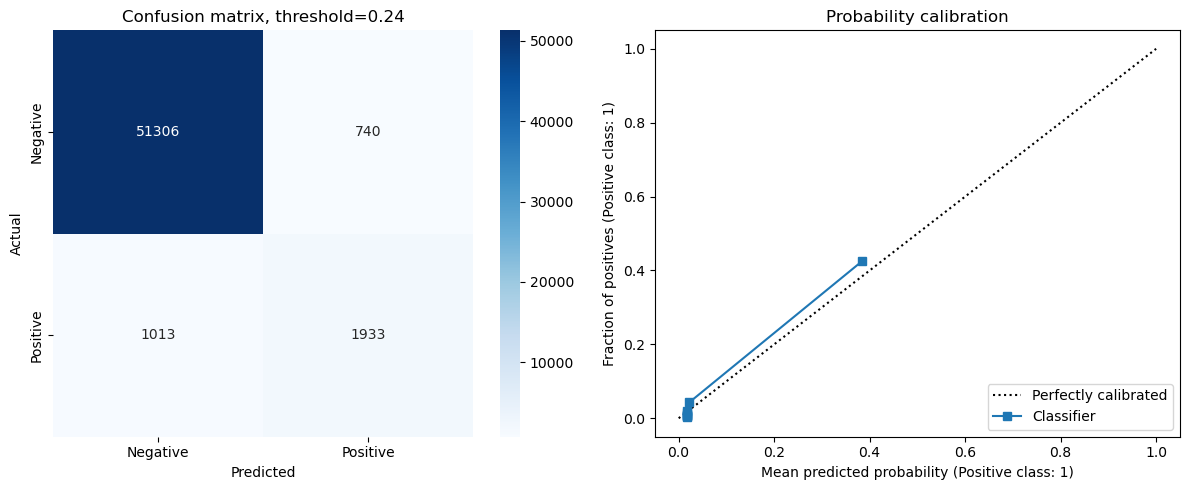

In [8]:
unscaled_results = main(
df,
scale_pos_weight=False,
calibration_method="sigmoid",
)

Training rows: 175971 (64.0%)
Validation rows: 43993 (16.0%)
Test rows: 54992 (20.0%)
Training positive rate: 0.0536
Validation positive rate: 0.0536
Test positive rate: 0.0536
scale_pos_weight: 17.669
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best cross-validation PR-AUC: 0.6872

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}

Applying sigmoid calibration...

Selected threshold: 0.4789
Validation precision: 0.7162
Validation recall: 0.6508
Validation F1: 0.6819

Final test-set results
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     52046
    Positive       0.71      0.66      0.69      2946

    accuracy                           0.97     54992
   macro avg       0.85      0.82      0.83     54992
weighted avg       0.97      0.97      0.97     54992

PR-AUC: 0.6949
ROC-AUC: 0.9107
Brier score: 0.0272


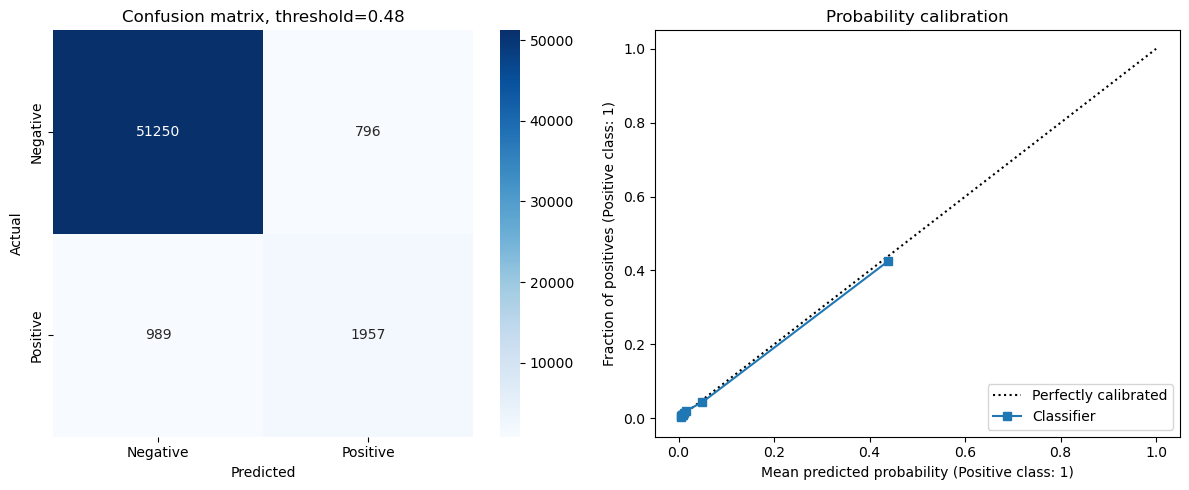

In [9]:
scaled_results = main(
    df,
    scale_pos_weight=True,
    calibration_method="sigmoid",
)